## Shor Algoritması

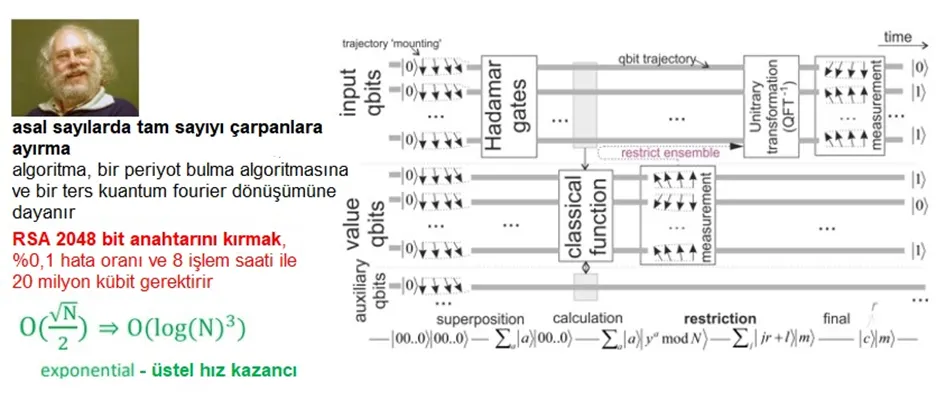

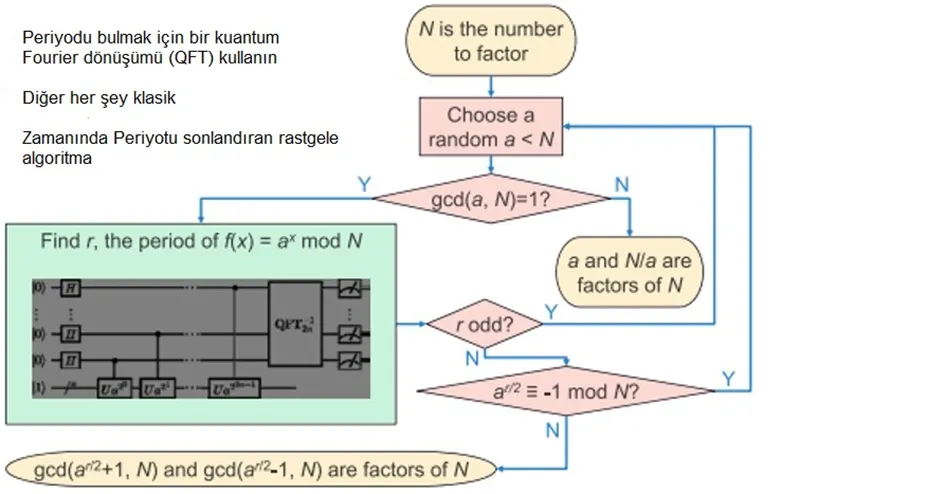




Üç aşamada çalışır: tamsayıyı çarpanlara ayırmak için ayrıştıran bir QFT (kuantum Fourier dönüşümü), bazı tekrarlara bakan periyot bulan bir problem çözücü ve algoritmanın periyot bulma kısmı tarafından elde edilen sonucu yeniden biçimlendiren bir ters QFT.

In [11]:
!pip install cirq
print("Cirq kütüphanesi yükleme komutu çalıştırıldı.")

Cirq kütüphanesi yükleme komutu çalıştırıldı.


In [2]:
import cirq

print("Cirq kütüphanesi başarıyla içe aktarıldı.")

Cirq kütüphanesi başarıyla içe aktarıldı.


Shor algoritması, kuantum bilgisayarlar için tasarlanmış devrim niteliğinde bir algoritmadır. Temel amacı, günümüz klasik bilgisayarlarının çözmekte zorlandığı büyük tam sayıları verimli bir şekilde çarpanlarına ayırmaktır. Bu yetenek, özellikle RSA gibi kamu anahtarlı şifreleme sistemleri için büyük bir tehdit oluşturmaktadır, çünkü bu sistemlerin güvenliği, büyük sayıları çarpanlarına ayırmanın zorluğuna dayanmaktadır. Kuantum bilgisayarların Shor algoritmasını kullanarak bu tür sayıları çarpanlarına ayırabilmesi, modern şifreleme protokollerinin zayıflamasına ve hatta kırılmasına yol açabilir.



Algoritma iki ana bölümden oluşur: klasik ön işleme ve kuantum bölümleri. Klasik kısım, çarpanlara ayırma problemini belirli bir fonksiyonun periyodunu bulma problemine indirgemek için kullanılır. Bu, klasik olarak normal (klasik) bir bilgisayar kullanılarak yapılabilir. Kuantum kısmı, sayıyı çarpanlarına ayırmak için kullanılan fonksiyonun periyodunu (sözde periyot bulma) verimli bir şekilde bulmak için bir kuantum hesaplama kullanır.

Shor’un algoritmasının ana hatları şu şekilde özetlenebilir:

1. Çarpanlarına ayırmak için N’yi seçin; burada N, p ve q olmak üzere iki asal çarpanı olan büyük bir bileşik sayıdır.

2. N’den küçük ve N’ye göre asal olan rastgele bir “a” sayısı seçin.

3. Kuantum Fourier Dönüşümü’nü (QFT), tüm olası durumların üst üste bindirildiği bir dizi n kübite uygulayın. Bu adım, periyodik fonksiyonun tüm olası değerlerinin eşit bir süperpozisyonunu üretir, f(x) = a^x mod N, burada x, 0 ile N-1 arasında bir tam sayıdır.

4. Periyodik fonksiyonun rasgele bir değeriyle sonuçlanan QFT’nin çıktısını ölçün, örneğin s. Bu ölçüm, durumların süperpozisyonunu tek bir duruma daraltır.

5. N ve (a^s/2) + 1 veya (a^s/2) — 1'in en büyük ortak bölenini (OBEB) hesaplayın. -önemsiz N faktörü. Aksi takdirde, önemsiz olmayan bir faktör bulunana kadar 2–5 arasındaki adımları tekrarlayın.

Shor’un algoritmasının kuantum kısmının, henüz mevcut olmayan büyük, hataya dayanıklı bir kuantum bilgisayarı gerektirdiğine dikkat etmek önemlidir. Bununla birlikte, büyük sayıları çarpanlarına ayırmanın zor bir sorun olduğu varsayımına dayalı olarak RSA şifreleme algoritmasını bozabileceğinden, algoritmanın veri güvenliği için önemli etkileri vardır.

## Shor Algoritmasının Temel Kavramları

### 1. Modüler Üs Alma (Modular Exponentiation)

Shor algoritmasının kalbinde, `a^x mod N` şeklinde ifade edilen modüler üs alma işlemi yatar. Burada:

*   `a`: Rastgele seçilen bir tam sayıdır (genellikle `1 < a < N` ve `gcd(a, N) = 1` koşulunu sağlar).
*   `x`: Üs olarak kullanılan tam sayıdır.
*   `N`: Çarpanlarına ayırmak istediğimiz büyük sayıdır.
*   `mod N`: İşlemin sonucunun `N`'ye bölümünden kalanı ifade eder.

Bu işlem, belirli bir `a` ve `N` için, `x` değiştikçe tekrarlayan bir dizi (`a^0 mod N`, `a^1 mod N`, `a^2 mod N`, ...) üretir. Shor algoritması, bu dizinin **periyodunu** bularak çalışır. Bu modüler üs alma işlemi, kuantum devreleri üzerinde etkili bir şekilde uygulanabilir.

### 2. Periyot Bulma (Period Finding)

Shor algoritmasının ana hedefi, yukarıda bahsedilen dizinin periyodunu (`r`) bulmaktır. Periyot `r`, `a^r ≡ 1 (mod N)` koşulunu sağlayan en küçük pozitif tam sayıdır. Bu `r` değeri, çarpanlara ayırma problemi için hayati önem taşır çünkü `N`'nin çarpanlarını bulmak için kullanılabilir. Eğer `r` çift ise ve `a^(r/2) ≢ -1 (mod N)` ise, `gcd(a^(r/2) - 1, N)` ve `gcd(a^(r/2) + 1, N)` işlemleri `N`'nin asal çarpanlarını verecektir. Bu nedenle, periyot bulma, algoritmanın en kritik adımıdır.

### 3. Kuantum Fourier Dönüşümü (Quantum Fourier Transform - QFT)

Periyot bulma problemi, klasik bilgisayarlar için oldukça zordur. Ancak, kuantum bilgisayarlar bu problemi Kuantum Fourier Dönüşümü (QFT) sayesinde çok daha verimli bir şekilde çözebilir. QFT, klasik Fourier dönüşümünün kuantum karşılığıdır ve bir kuantum durumunun süperpozisyonundaki farklı frekans bileşenlerini (bu durumda periyoda karşılık gelir) ortaya çıkarmak için kullanılır. QFT'nin uygulanmasıyla, modüler üs alma işleminden elde edilen periyodik dizinin periyodu, kuantum bitlerinin ölçümü sonucunda yüksek olasılıkla elde edilir. Bu, Shor algoritmasına klasik algoritmalar karşısında üstünlük sağlayan temel kuantum mekanizmasıdır.

Shor algoritmasının kalbinde, büyük bir N sayısının asal çarpanlarını bulmak için f(x) = a^x mod N periyodik fonksiyonunun periyodunu (r) bulma problemi yatar. Klasik bilgisayarlar için bu problem zorludur, ancak kuantum bilgisayarlar QFT sayesinde bunu polinom zamanda çözebilir.

QFT'nin Shor algoritmasındaki rolü şunlardır:

Süperpozisyon Oluşturma: İlk olarak, f(x) fonksiyonunun periyodunu bulmak için kullanılacak giriş yazmacı (register) bir süperpozisyon durumuna getirilir.
Modüler Üs Alma (Uygulama): Ardından, f(x) = a^x mod N fonksiyonu kuantum devresi olarak uygulanır. Bu işlem, çıkış yazmacında a^x mod N değerine karşılık gelen durumları oluştururken, giriş yazmacı hala x değerlerinin süperpozisyonundadır. Bu adım, periyodik bir örüntüye sahip bir kuantum durumu yaratır.
Kuantum Fourier Dönüşümü Uygulama: İşte QFT'nin devreye girdiği yer burasıdır. Modüler üs alma işleminden sonra elde edilen periyodik kuantum durumuna QFT uygulanır. QFT'nin en önemli özelliği, periyodik fonksiyonların frekanslarını (yani periyotlarını) yüksek olasılıkla ölçülebilir durumlara dönüştürmesidir. Periyodik bir durumun QFT'si, periyodun katlarına karşılık gelen frekans bileşenlerinde genlikleri yoğunlaştırır.
Ölçüm ve Periyot Çıkarımı: QFT'den sonra, çıkış yazmacı ölçülür. Bu ölçüm sonuçları, periyodun rasyonel bir yaklaşımını verir. Elde edilen bu rasyonel yaklaşımlar (kesirler), klasik kesir zinciri algoritmaları kullanılarak periyot r'yi bulmak için işlenir. Bu, Shor algoritmasının nihayetinde büyük sayıları çarpanlarına ayırmasını sağlayan kritik adımdır.
Özetle, QFT, a^x mod N gibi periyodik fonksiyonların gizli periyotlarını, kuantum durumundaki faz bilgisine kodlanmış frekans bileşenlerini ortaya çıkararak bulmamızı sağlar. Bu, klasik algoritmaların üstesinden gelemeyeceği bir gücü kuantum hesaplamaya kazandırır.




## Modüler Üs Alma Devresi (Basitleştirilmiş)

Shor algoritmasının önemli bir bileşeni olan modüler üs alma işlemini (örneğin, $a^x \pmod N$) gösteren basitleştirilmiş bir Cirq devresi. Bu, algoritmanın anahtarı olan periyodik fonksiyonu oluşturmayı hedefleyecektir.


In [3]:
N = 15  # Sayıyı çarpanlarına ayıracağız
a = 7   # Rastgele seçilen taban

print(f"Seçilen N değeri: {N}")
print(f"Seçilen a değeri: {a}")

Seçilen N değeri: 15
Seçilen a değeri: 7


`N`'yi ve modüler üs alma işleminin sonucunu temsil etmek için gereken minimum kuantum bit sayısını belirlemem gerekiyor. Bu, `ceil(log2(N))` kullanılarak hesaplanabilir.



In [4]:
import math

# N'yi temsil etmek için gereken minimum qubit sayısı
num_qubits_N = math.ceil(math.log2(N))
print(f"N ({N}) değerini temsil etmek için gereken minimum qubit sayısı: {num_qubits_N}")

N (15) değerini temsil etmek için gereken minimum qubit sayısı: 4


kontrol kaydı için `num_qubits_N` ile aynı sayıda kuantum bitini kullanmam gerekiyor. Bu, modüler üs alma işlemi için giriş kaydının boyutunu tanımlayacaktır.



In [5]:
num_qubits_control = num_qubits_N
print(f"Kontrol register'ı için gereken qubit sayısı: {num_qubits_control}")

Kontrol register'ı için gereken qubit sayısı: 4


`cirq.Gate` sınıfından miras alan özel bir `SimplifiedModularExponentiation` sınıfı tanımlamam gerekiyor. Bu sınıf, tam kuantum kapılarını uygulamadan kavramsal olarak modüler üs alma işlemini temsil edecektir.



In [6]:
class SimplifiedModularExponentiation(cirq.Gate):
    def __init__(self, a: int, N: int, control_qubit_count: int, target_qubit_count: int):
        self.a = a
        self.N = N
        self._num_qubits = control_qubit_count + target_qubit_count

    def num_qubits(self) -> int:
        return self._num_qubits

    def __str__(self) -> str:
        return f"ModularExp(a={self.a}, N={self.N})"

print("SimplifiedModularExponentiation sınıfı tanımlandı.")

SimplifiedModularExponentiation sınıfı tanımlandı.


`cirq.LineQubit.range()` kullanarak modüler üs alma devresi için kontrol ve hedef kuantum bitlerini oluşturmam gerekiyor. Hedef kuantum bitlerinin sayısı `num_qubits_N` (4) ve kontrol kuantum bitlerinin sayısı `num_qubits_control` (aynı şekilde 4) olacaktır.



`cirq.LineQubit.range()` işlevinin `prefix` argümanını kabul etmemesi nedeniyle hata verdi. Talimatta belirtildiği gibi `cirq.LineQubit.range()` işlevini kullanmaya devam ederken bu sorunu gidermek için, `prefix` argümanını kaldıracağım ve tüm kuantum bitlerinin benzersiz olmasını sağlamak için hedef kuantum bitlerinin başlangıç indeksini ayarlayacağım.



In [7]:
num_qubits_target = num_qubits_N # Target register için N'yi temsil eden qubit sayısı

control_qubits = cirq.LineQubit.range(num_qubits_control) # Kontrol register'ı qubit'leri
target_qubits = cirq.LineQubit.range(num_qubits_control, num_qubits_control + num_qubits_target) # Hedef register'ı qubit'leri

print(f"Kontrol qubit'leri: {control_qubits}")
print(f"Hedef qubit'leri: {target_qubits}")

Kontrol qubit'leri: [cirq.LineQubit(0), cirq.LineQubit(1), cirq.LineQubit(2), cirq.LineQubit(3)]
Hedef qubit'leri: [cirq.LineQubit(4), cirq.LineQubit(5), cirq.LineQubit(6), cirq.LineQubit(7)]


önceden tanımlanmış `a`, `N`, `num_qubits_control` ve `num_qubits_target` değerlerini kullanarak `SimplifiedModularExponentiation` sınıfının bir örneğini oluşturmam gerekiyor.



In [8]:
modular_exponentiation_gate = SimplifiedModularExponentiation(a, N, num_qubits_control, num_qubits_target)

print(f"Modüler üs alma kapısı örneği oluşturuldu: {modular_exponentiation_gate}")

Modüler üs alma kapısı örneği oluşturuldu: ModularExp(a=7, N=15)


bir `cirq.Circuit` nesnesi oluşturmam ve `modular_exponentiation_gate`'i kontrol ve hedef kuantum bitlerinin birleşik kümesine uygulamam gerekiyor.



In [9]:
circuit = cirq.Circuit()
circuit.append(modular_exponentiation_gate.on(*control_qubits, *target_qubits))

print("Cirq devresi oluşturuldu ve modüler üs alma kapısı uygulandı.")

Cirq devresi oluşturuldu ve modüler üs alma kapısı uygulandı.


oluşturulan Cirq devresini yapısını görselleştirmek için yazdırmam gerekiyor.



In [10]:
print("Oluşturulan basitleştirilmiş modüler üs alma devresi:")
print(circuit)

Oluşturulan basitleştirilmiş modüler üs alma devresi:
0: ───ModularExp(a=7, N=15)───
      │
1: ───#2──────────────────────
      │
2: ───#3──────────────────────
      │
3: ───#4──────────────────────
      │
4: ───#5──────────────────────
      │
5: ───#6──────────────────────
      │
6: ───#7──────────────────────
      │
7: ───#8──────────────────────


### Modüler Üs Alma Devresinin Shor Algoritmasındaki Rolü

Yukarıda oluşturduğumuz basitleştirilmiş Cirq devresi, Shor algoritmasının temelini oluşturan $a^x \pmod N$ periyodik fonksiyonunun kuantum devresi üzerindeki **kavramsal** temsilidir. Gerçek bir kuantum devresinde bu işlem, daha karmaşık ve çok sayıda temel kuantum kapısı kullanılarak gerçekleştirilir. Ancak, bu basitleştirilmiş `ModularExp` kapısı, Shor algoritmasının mantığını anlamak için yeterli bir soyutlama sağlar.

Bu devre, Shor algoritmasının **periyot bulma** aşamasında kritik bir rol oynar. Algoritma, iki kuantum yazmacı kullanır:

1.  **Kontrol Yazmacı (Control Register)**: Bu yazmaç, $x$ değerlerini (üsleri) tutar ve süperpozisyon durumunda bulunur. Yani, tüm olası $x$ değerlerini aynı anda temsil eder.
2.  **Hedef Yazmacı (Target Register)**: Bu yazmaç başlangıçta $|0\rangle$ durumundadır ve modüler üs alma işleminin sonucunu saklar.

`ModularExp` kapısı, kontrol yazmacındaki her bir $|x\rangle$ durumu için hedef yazmacına karşılık gelen $a^x \pmod N$ değerini yazar. Kavramsal olarak, bu kapı aşağıdaki dönüşümü gerçekleştirir:

$$|x\rangle|0\rangle \rightarrow |x\rangle|a^x \pmod N\rangle$$

Bu dönüşüm sonucunda, hedef yazmacı, $x$ değerlerine bağlı olarak $a^x \pmod N$ fonksiyonunun periyodik çıktısını içeren bir süperpozisyon durumuna gelir. Kuantum Fourier Dönüşümü (QFT) bu periyodik yapıyı analiz ederek periyot $r$'yi elde etmemizi sağlar. Bu sayede, Shor algoritması büyük sayıları çarpanlarına ayırma işlemini kuantum hızında gerçekleştirebilir.

In [12]:
import cirq
import math # Import the math module for math.pi

def qft_circuit(qubits):
    """Applies the Quantum Fourier Transform to a list of qubits."""
    n = len(qubits)
    circuit = cirq.Circuit()

    # Apply QFT operations
    for i in range(n):
        # Apply Hadamard gate
        circuit.append(cirq.H(qubits[i]))

        # Apply controlled phase rotations
        for j in range(i + 1, n):
            angle = -2 * math.pi / (2**(j - i + 1)) # Use math.pi instead of float('pi')
            circuit.append(cirq.CZ(qubits[j], qubits[i])**angle)

    # Swap qubits to reverse the order (standard QFT output)
    for i in range(n // 2):
        circuit.append(cirq.SWAP(qubits[i], qubits[n - 1 - i]))

    return circuit

# Create 3 qubits for a small-scale QFT
q = cirq.LineQubit.range(3)

# Build the QFT circuit
qft_3_qubit_circuit = qft_circuit(q)

# Print the circuit
print("3-Qubit QFT Circuit:")
print(qft_3_qubit_circuit)

3-Qubit QFT Circuit:
                    ┌───────────┐
0: ───H───@──────────@────────────────────────────×───
          │          │                            │
1: ───────@^(3/7)────┼─────────H────@─────────────┼───
                     │              │             │
2: ──────────────────@^(-11/14)─────@^(3/7)───H───×───
                    └───────────┘


https://quantumai.google/cirq/experiments/shor